# Optimizadores Basados en Gradiente

Se analizan 6 algoritmos de optimización sobre la **Función de Himmelblau**:

$$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$$

Esta función tiene **4 mínimos globales**, lo que permite comparar la convergencia de cada algoritmo desde un mismo punto de inicio.

In [174]:
import numpy as np
import matplotlib.pyplot as plt

## Definición de la Función y su Gradiente

Se utilizan la función de Himmelblau y su gradiente analítico. Además se define una función auxiliar para graficar el mapa de contorno y un punto de inicio común para todos los optimizadores.

In [175]:
def f(x, y):
    """Función de Himmelblau: 4 mínimos globales en f=0."""
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def grad_f(x, y):
    """Gradiente analítico de la función de Himmelblau."""
    df_dx = 4 * x * (x**2 + y - 11) + 2 * (x + y**2 - 7)
    df_dy = 2 * (x**2 + y - 11) + 4 * y * (x + y**2 - 7)
    return np.array([df_dx, df_dy])

def plot_contour(ax, title, path, color):
    """Dibuja el mapa de contorno con la trayectoria del optimizador."""
    x_vals = np.linspace(-5, 5, 300)
    y_vals = np.linspace(-5, 5, 300)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = f(X, Y)

    ax.contourf(X, Y, Z, levels=50, cmap='plasma', alpha=0.7)
    ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.4, alpha=0.3)

    # Marcar los 4 mínimos conocidos de la función
    for mx, my in [(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]:
        ax.plot(mx, my, 'w*', markersize=10)

    # Dibujar la trayectoria del optimizador
    ax.plot(path[:, 0], path[:, 1], color=color, marker='.', ms=3, lw=1.5, label=title)
    ax.plot(path[0, 0], path[0, 1], 'go', ms=8, label='Inicio')
    ax.plot(path[-1, 0], path[-1, 1], 'rs', ms=8, label='Final')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)

# Punto de inicio y número de iteraciones comunes para todos los optimizadores
START   = np.array([0.0, -1])
N_ITERS = 1000
EPS     = 1e-8  # Constante de estabilidad numérica (evita división por cero)

## SGD

**Stochastic Gradient Descent (SGD):** actualiza los parámetros restando una fracción fija (`lr`) del gradiente en cada paso. Es el método más simple pero puede ser lento y sensible a la tasa de aprendizaje.

In [176]:
def sgd(start, lr=0.005, n_iters=N_ITERS, tol=1e-6):
    x = start.copy()
    path = [x.copy()]
    iters = 0
    for i in range(n_iters):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:  # Condición de parada: gradiente suficientemente pequeño
            break
        x -= lr * g            # Regla de actualización: x = x - lr * ∇f
        path.append(x.copy())
        iters = i + 1

    return np.array(path), iters

path_sgd, iters_sgd = sgd(START)
print(f"SGD → Final: ({path_sgd[-1,0]:.4f}, {path_sgd[-1,1]:.4f}) | f = {f(*path_sgd[-1]):.6f} | Iteraciones: {iters_sgd}")

SGD → Final: (3.5844, -1.8481) | f = 0.000000 | Iteraciones: 133


## RMSprop

**RMSprop:** divide la tasa de aprendizaje por la raíz de una media móvil exponencial de los cuadrados del gradiente. Esto adapta el `lr` por dimensión y evita que se vuelva demasiado pequeño.

$$v_t = \rho \, v_{t-1} + (1-\rho)\, g_t^2 \qquad x_t = x_{t-1} - \frac{lr}{\sqrt{v_t + \varepsilon}}\, g_t$$

In [177]:
def rmsprop(start, lr=0.01, rho=0.9, n_iters=N_ITERS, tol=1e-6):
    x = start.copy()
    v = np.zeros(2)          # Media móvil de gradientes al cuadrado
    path = [x.copy()]
    iters = 0
    for i in range(n_iters):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        v = rho * v + (1 - rho) * g**2
        x -= (lr / np.sqrt(v + EPS)) * g
        path.append(x.copy())
        iters = i + 1

    return np.array(path), iters

path_rmsprop, iters_rmsprop = rmsprop(START)
print(f"RMSprop → Final: ({path_rmsprop[-1,0]:.4f}, {path_rmsprop[-1,1]:.4f}) | f = {f(*path_rmsprop[-1]):.6f} | Iteraciones: {iters_rmsprop}")

RMSprop → Final: (3.0000, 2.0000) | f = 0.000000 | Iteraciones: 343


## Adam

**Adam (Adaptive Moment Estimation):** combina un momento de primer orden (media del gradiente) y uno de segundo orden (varianza). Aplica corrección de sesgo en los primeros pasos para compensar la inicialización en cero.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad x_t = x_{t-1} - \frac{lr\,\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}$$

In [178]:
def adam(start, lr=0.1, beta1=0.9, beta2=0.999, n_iters=N_ITERS, tol=1e-6):
    x = start.copy()
    m = np.zeros(2)    # Primer momento (media del gradiente)
    v = np.zeros(2)    # Segundo momento (varianza del gradiente)
    path = [x.copy()]
    iters = 0
    for t in range(1, n_iters + 1):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)   # Corrección de sesgo
        v_hat = v / (1 - beta2**t)
        x -= lr * m_hat / (np.sqrt(v_hat) + EPS)
        path.append(x.copy())
        iters = t

    return np.array(path), iters

path_adam, iters_adam = adam(START)
print(f"Adam → Final: ({path_adam[-1,0]:.4f}, {path_adam[-1,1]:.4f}) | f = {f(*path_adam[-1]):.6f} | Iteraciones: {iters_adam}")

Adam → Final: (3.0000, 2.0000) | f = 0.000000 | Iteraciones: 329


## Adadelta

**Adadelta:** extensión de Adagrad que no acumula todos los gradientes históricos, sino solo una ventana deslizante. Tampoco requiere especificar una tasa de aprendizaje global; la escala de actualización se infiere de los propios parámetros.

$$E[g^2]_t = \rho\, E[g^2]_{t-1} + (1-\rho)\, g_t^2 \qquad \Delta x_t = -\frac{\sqrt{E[\Delta x^2]_{t-1}+\varepsilon}}{\sqrt{E[g^2]_t+\varepsilon}}\, g_t$$

In [179]:
def adadelta(start, rho=0.95, n_iters=N_ITERS, tol=1e-6):
    x    = start.copy()
    Eg2  = np.zeros(2)    # Media móvil de gradientes al cuadrado
    Edx2 = np.zeros(2)    # Media móvil de actualizaciones al cuadrado
    path = [x.copy()]
    iters = 0
    for i in range(n_iters):
        g    = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        Eg2  = rho * Eg2  + (1 - rho) * g**2
        dx   = -(np.sqrt(Edx2 + EPS) / np.sqrt(Eg2 + EPS)) * g
        Edx2 = rho * Edx2 + (1 - rho) * dx**2
        x   += dx
        path.append(x.copy())
        iters = i + 1

    return np.array(path), iters

path_adadelta, iters_adadelta = adadelta(START)
print(f"Adadelta → Final: ({path_adadelta[-1,0]:.4f}, {path_adadelta[-1,1]:.4f}) | f = {f(*path_adadelta[-1]):.6f} | Iteraciones: {iters_adadelta}")

Adadelta → Final: (-1.7483, 3.0875) | f = 24.195108 | Iteraciones: 1000


## Adagrad

**Adagrad:** adapta la tasa de aprendizaje por parámetro acumulando la suma de todos los cuadrados del gradiente desde el inicio. Útil para datos dispersos, pero la tasa decrece indefinidamente con el tiempo.

$$G_t = G_{t-1} + g_t^2 \qquad x_t = x_{t-1} - \frac{lr}{\sqrt{G_t + \varepsilon}}\, g_t$$

In [180]:
def adagrad(start, lr=0.5, n_iters=N_ITERS, tol=1e-6):
    x = start.copy()
    G = np.zeros(2)    # Suma acumulada de gradientes al cuadrado
    path = [x.copy()]
    iters = 0
    for i in range(n_iters):
        g  = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        G += g**2
        x -= (lr / np.sqrt(G + EPS)) * g
        path.append(x.copy())
        iters = i + 1

    return np.array(path), iters

path_adagrad, iters_adagrad = adagrad(START)
print(f"Adagrad → Final: ({path_adagrad[-1,0]:.4f}, {path_adagrad[-1,1]:.4f}) | f = {f(*path_adagrad[-1]):.6f} | Iteraciones: {iters_adagrad}")

Adagrad → Final: (3.0000, 2.0000) | f = 0.000000 | Iteraciones: 98


##  Nadam

**Nadam (Nesterov-accelerated Adam):** incorpora el momento de Nesterov en Adam. En lugar de usar el momento actual para la actualización, anticipa el gradiente en la posición futura, logrando una convergencia más suave.

$$\hat{m}^{\text{Nesterov}}_t = \frac{\beta_1\, m_t}{1-\beta_1^{t+1}} + \frac{(1-\beta_1)\, g_t}{1-\beta_1^t} \qquad x_t = x_{t-1} - \frac{lr\,\hat{m}^{\text{Nesterov}}_t}{\sqrt{\hat{v}_t}+\varepsilon}$$

In [181]:
def nadam(start, lr=0.1, beta1=0.9, beta2=0.999, n_iters=N_ITERS, tol=1e-6):
    x = start.copy()
    m = np.zeros(2)    # Primer momento
    v = np.zeros(2)    # Segundo momento
    path = [x.copy()]
    iters = 0
    for t in range(1, n_iters + 1):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        v_hat = v / (1 - beta2**t)
        # Anticipación de Nesterov: combina momento corregido y gradiente actual
        m_nesterov = (beta1 * m / (1 - beta1**(t + 1))) + ((1 - beta1) * g / (1 - beta1**t))
        x -= lr * m_nesterov / (np.sqrt(v_hat) + EPS)
        path.append(x.copy())
        iters = t

    return np.array(path), iters

path_nadam, iters_nadam = nadam(START)

print(f"Nadam → Final: ({path_nadam[-1,0]:.4f}, {path_nadam[-1,1]:.4f}) | f = {f(*path_nadam[-1]):.6f} | Iteraciones: {iters_nadam}")


Nadam → Final: (3.0000, 2.0000) | f = 0.000000 | Iteraciones: 256


## Visualización Individual de Optimizadores

Cada subgráfica muestra la trayectoria de un optimizador sobre el mapa de calor de la función. Las **estrellas blancas** indican los 4 mínimos globales, el **punto verde** es el punto de inicio y el **cuadrado rojo** es donde convergió el algoritmo.

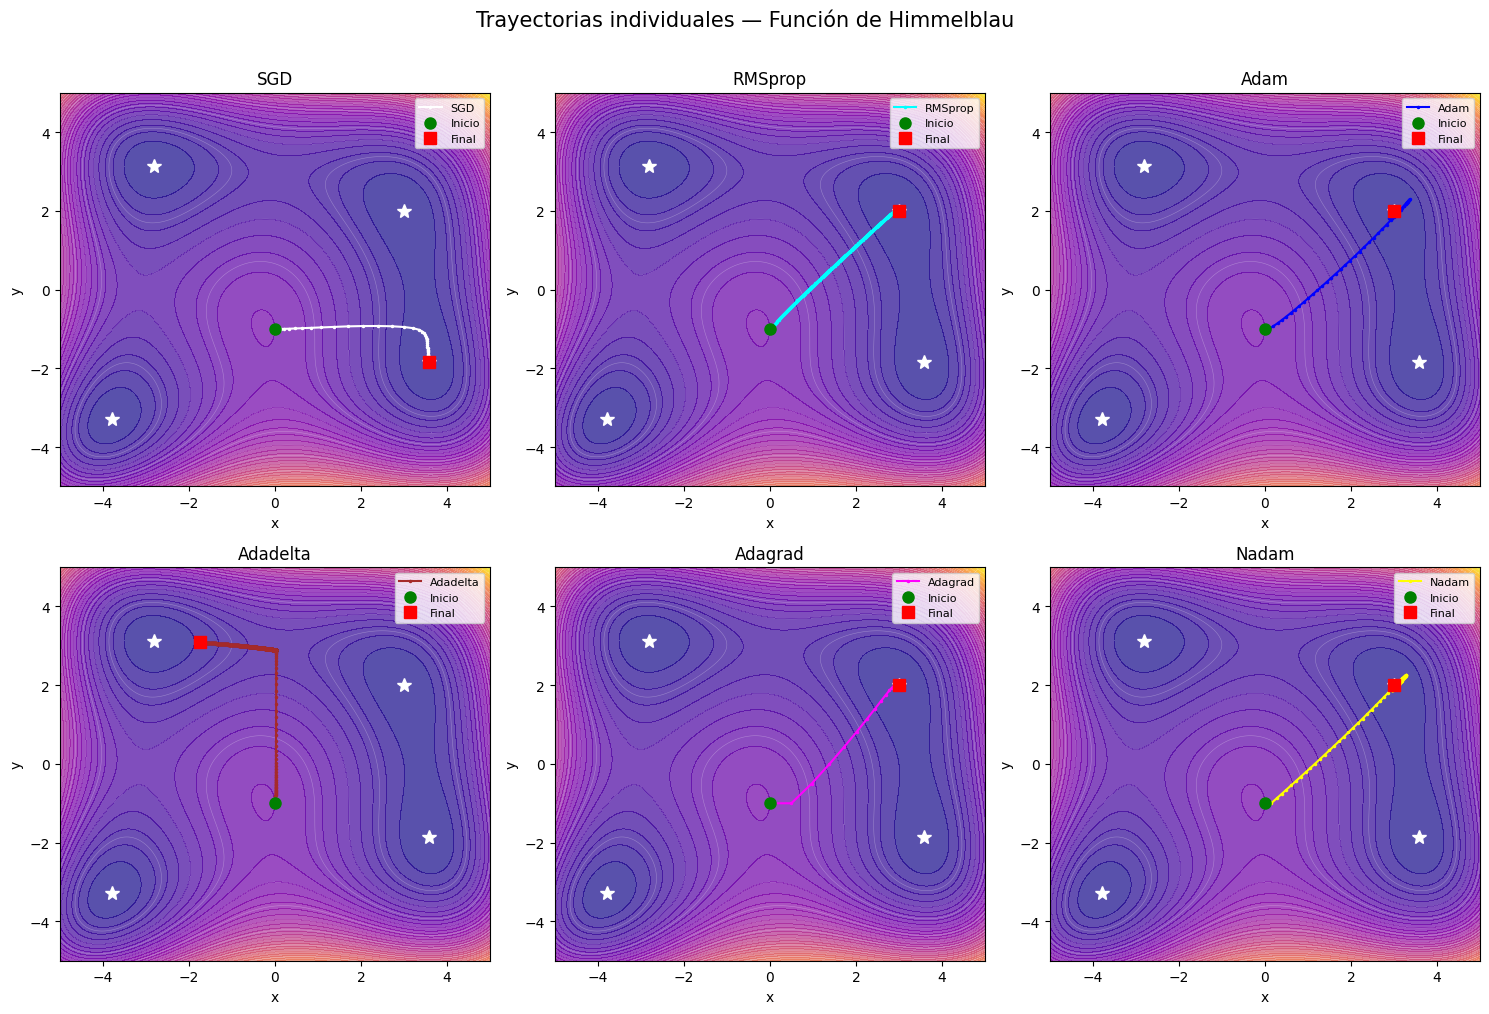

In [186]:
optimizers_info = [
    ("SGD",      path_sgd,      "white",   iters_sgd),
    ("RMSprop",  path_rmsprop,  "cyan",    iters_rmsprop),
    ("Adam",     path_adam,     "blue",    iters_adam),
    ("Adadelta", path_adadelta, "brown",   iters_adadelta),
    ("Adagrad",  path_adagrad,  "magenta", iters_adagrad),
    ("Nadam",    path_nadam,    "yellow",  iters_nadam),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, path, color, iters) in zip(axes, optimizers_info):
    plot_contour(ax, f"{name}", path, color)

plt.suptitle("Trayectorias individuales — Función de Himmelblau", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Visualización Combinada de Trayectorias

Todas las trayectorias superpuestas en un único mapa de contorno, lo que permite comparar directamente la ruta elegida por cada algoritmo desde el mismo punto de inicio.

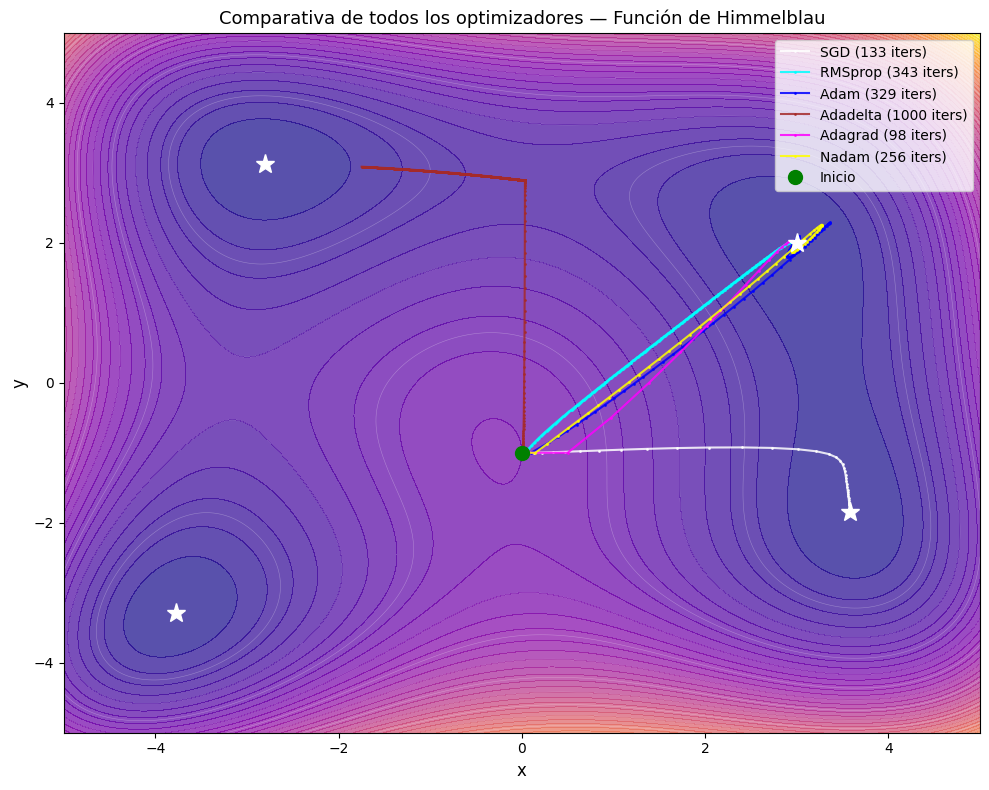

In [185]:
# Mapa de contorno base
x_vals = np.linspace(-5, 5, 300)
y_vals = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(X, Y, Z, levels=50, cmap='plasma', alpha=0.7)
ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.4, alpha=0.3)

# Mínimos globales
for mx, my in [(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]:
    ax.plot(mx, my, 'w*', markersize=14, zorder=5)

# Trazar cada trayectoria
for name, path, color, iters in optimizers_info:
    ax.plot(path[:, 0], path[:, 1], color=color, lw=1.5, marker='.', ms=2, alpha=0.85, label=f"{name} ({iters} iters)")

# Punto de inicio
ax.plot(START[0], START[1], 'go', ms=10, zorder=6, label='Inicio')

ax.set_title("Comparativa de todos los optimizadores — Función de Himmelblau", fontsize=13)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()